# CELL 1 — Imports & Load Data for Backtesting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

# ECL final results from notebook 05
ecl_df = pd.read_csv('../data/ecl_final_results.csv')

# Calibrated PD predictions from notebook 02
# These are already Platt-scaled — no recalibration needed here
pd_preds = pd.read_csv('../data/pd_predictions.csv')

# PD predictions with issue_year for OOT PSI
pd_preds_year = pd.read_csv('../data/pd_predictions_with_year.csv')

print("Data loaded for backtesting")
print(f"   ECL results       : {len(ecl_df):,} loans")
print(f"   PD test set       : {len(pd_preds):,} loans")
print(f"   PD with year      : {len(pd_preds_year):,} loans")
print(f"\n   PD predictions columns  : {list(pd_preds.columns)}")
print(f"   Issue years available   : "
      f"{sorted(pd_preds_year['issue_year'].unique().tolist())}")
print(f"\n   Backtesting overview:")
print(f"   Test 1 — Kupiec Test    : statistical calibration accuracy")
print(f"   Test 2 — Traffic Light  : Basel II/III compliance zone")
print(f"   Test 3 — Calibration    : bucket-level PD accuracy")
print(f"   Test 4 — OOT PSI        : population stability 2007-2016 vs 2017-2018")

Data loaded for backtesting
   ECL results       : 122,216 loans
   PD test set       : 24,444 loans
   PD with year      : 24,444 loans

   PD predictions columns  : ['id', 'issue_year', 'actual_default', 'pd_raw', 'pd_probability', 'pd_predicted']
   Issue years available   : [2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0]

   Backtesting overview:
   Test 1 — Kupiec Test    : statistical calibration accuracy
   Test 2 — Traffic Light  : Basel II/III compliance zone
   Test 3 — Calibration    : bucket-level PD accuracy
   Test 4 — OOT PSI        : population stability 2007-2016 vs 2017-2018


# Cell 2 - Regulatory Backtesting: Kupiec + Traffic Light + Calibration

In [2]:
actual_defaults   = pd_preds['actual_default'].sum()
total_loans       = len(pd_preds)
mean_predicted_pd = pd_preds['pd_probability'].mean()
actual_dr         = pd_preds['actual_default'].mean()

# ── 1. KUPIEC TEST ──────────────────────────────────────────
# Likelihood ratio test for calibration accuracy
# H0: predicted default rate = actual default rate
# p-value > 0.05 = pass

p = mean_predicted_pd
x = actual_defaults
n = total_loans

LR_stat = -2 * (
    x * np.log(p) + (n - x) * np.log(1 - p)
    - x * np.log(x / n) - (n - x) * np.log(1 - (x / n))
)
p_value = 1 - stats.chi2.cdf(LR_stat, df=1)

kupiec_pass = p_value > 0.05

print("=" * 55)
print("1. KUPIEC TEST")
print("=" * 55)
print(f"   Predicted default rate : {mean_predicted_pd:.4f} ({mean_predicted_pd*100:.2f}%)")
print(f"   Actual default rate    : {actual_dr:.4f} ({actual_dr*100:.2f}%)")
print(f"   LR statistic           : {LR_stat:.4f}")
print(f"   p-value                : {p_value:.4f}")
print(f"   Result : {'PASS — Model calibration acceptable' if kupiec_pass else 'FAIL — Model needs recalibration'}")

# ── 2. TRAFFIC LIGHT TEST ───────────────────────────────────
# Basel II standard: deviation between expected and actual defaults
# Green < 20%, Amber 20-40%, Red > 40%

expected_defaults = mean_predicted_pd * total_loans
deviation_pct     = abs(actual_defaults - expected_defaults) / expected_defaults * 100

if deviation_pct < 20:
    zone       = "GREEN — Model performing well"
    zone_color = "green"
elif deviation_pct < 40:
    zone       = "AMBER — Monitor closely"
    zone_color = "amber"
else:
    zone       = "RED — Model needs recalibration"
    zone_color = "red"

tl_pass = deviation_pct < 20

print(f"\n{'=' * 55}")
print("2. TRAFFIC LIGHT TEST (Basel II)")
print("=" * 55)
print(f"   Expected defaults : {expected_defaults:,.0f}")
print(f"   Actual defaults   : {actual_defaults:,}")
print(f"   Deviation         : {deviation_pct:.2f}%")
print(f"   Zone              : {zone}")

# ── 3. CALIBRATION TEST ─────────────────────────────────────
# Group into 10 PD buckets — check if actual DR matches predicted PD
# Mean calibration error < 0.10 = pass

pd_preds['pd_bucket'] = pd.qcut(
    pd_preds['pd_probability'], 10, duplicates='drop'
)
calibration = pd_preds.groupby('pd_bucket', observed=True).agg(
    predicted_pd = ('pd_probability', 'mean'),
    actual_dr    = ('actual_default', 'mean'),
    count        = ('actual_default', 'count')
).round(4)
calibration['deviation'] = abs(
    calibration['predicted_pd'] - calibration['actual_dr']
)
mean_calib_error = calibration['deviation'].mean()
calib_pass       = mean_calib_error < 0.10

print(f"\n{'=' * 55}")
print("3. CALIBRATION TEST")
print("=" * 55)
print(calibration.to_string())
print(f"\n   Mean calibration error : {mean_calib_error:.4f}")
print(f"   Result : {'PASS — Well calibrated' if calib_pass else 'REVIEW — Calibration error high'}")

1. KUPIEC TEST
   Predicted default rate : 0.2192 (21.92%)
   Actual default rate    : 0.2185 (21.85%)
   LR statistic           : 0.0685
   p-value                : 0.7935
   Result : PASS — Model calibration acceptable

2. TRAFFIC LIGHT TEST (Basel II)
   Expected defaults : 5,358
   Actual defaults   : 5,341
   Deviation         : 0.32%
   Zone              : GREEN — Model performing well

3. CALIBRATION TEST
                 predicted_pd  actual_dr  count  deviation
pd_bucket                                                 
(0.0119, 0.063]        0.0443     0.0495   2445     0.0052
(0.063, 0.0941]        0.0785     0.0831   2444     0.0046
(0.0941, 0.126]        0.1101     0.1215   2444     0.0114
(0.126, 0.16]          0.1425     0.1448   2445     0.0023
(0.16, 0.196]          0.1776     0.1854   2444     0.0078
(0.196, 0.234]         0.2149     0.2042   2444     0.0107
(0.234, 0.277]         0.2550     0.2601   2445     0.0051
(0.277, 0.333]         0.3041     0.2934   2444     0

# Cell 3 - Out-of-Time PSI (2007-2016 vs 2017-2018)

In [3]:
train_window = pd_preds_year[pd_preds_year['issue_year'] <= 2016]
oot_window   = pd_preds_year[pd_preds_year['issue_year'] >= 2017]

print("OOT PSI — Population Stability Index")
print(f"\n   Training window (2007-2016) : {len(train_window):,} loans")
print(f"   OOT window (2017-2018)      : {len(oot_window):,} loans")

if len(train_window) == 0 or len(oot_window) == 0:
    print("\n   WARNING: One window is empty — check issue_year values")
    print(f"   Unique years in data: {sorted(pd_preds_year['issue_year'].unique())}")
else:
    bins = np.linspace(0, 1, 11)

    train_dist = np.histogram(train_window['pd_probability'], bins=bins)[0]
    oot_dist   = np.histogram(oot_window['pd_probability'],   bins=bins)[0]

    # Normalise to proportions
    train_dist = train_dist / len(train_window)
    oot_dist   = oot_dist   / len(oot_window)

    # Epsilon to avoid log(0)
    train_dist = np.where(train_dist == 0, 1e-4, train_dist)
    oot_dist   = np.where(oot_dist   == 0, 1e-4, oot_dist)

    psi = np.sum((oot_dist - train_dist) * np.log(oot_dist / train_dist))

    if psi < 0.10:
        psi_result = "STABLE — No retraining needed"
    elif psi < 0.25:
        psi_result = "MONITOR — Slight population shift"
    else:
        psi_result = "UNSTABLE — Model retraining required"

    print(f"\n{'=' * 55}")
    print("4. PSI — OUT-OF-TIME POPULATION STABILITY INDEX")
    print("=" * 55)
    print(f"   Training window mean PD : {train_window['pd_probability'].mean():.4f}")
    print(f"   OOT window mean PD      : {oot_window['pd_probability'].mean():.4f}")
    print(f"\n   PSI value : {psi:.4f}")
    print(f"   Result    : {psi_result}")
    print(f"\n   Benchmark : PSI < 0.10 stable | 0.10-0.25 monitor | >0.25 retrain")

    print(f"\n   Bucket-level breakdown:")
    bin_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
    for i, label in enumerate(bin_labels):
        bucket_psi = (oot_dist[i] - train_dist[i]) * np.log(oot_dist[i] / train_dist[i])
        print(f"   PD {label} : train={train_dist[i]:.4f} "
              f"oot={oot_dist[i]:.4f}  bucket PSI={bucket_psi:.4f}")

OOT PSI — Population Stability Index

   Training window (2007-2016) : 20,048 loans
   OOT window (2017-2018)      : 4,396 loans

4. PSI — OUT-OF-TIME POPULATION STABILITY INDEX
   Training window mean PD : 0.2144
   OOT window mean PD      : 0.2412

   PSI value : 0.0466
   Result    : STABLE — No retraining needed

   Benchmark : PSI < 0.10 stable | 0.10-0.25 monitor | >0.25 retrain

   Bucket-level breakdown:
   PD 0.0-0.1 : train=0.2245 oot=0.1868  bucket PSI=0.0069
   PD 0.1-0.2 : train=0.2995 oot=0.2648  bucket PSI=0.0043
   PD 0.2-0.3 : train=0.2316 oot=0.2395  bucket PSI=0.0003
   PD 0.3-0.4 : train=0.1390 oot=0.1497  bucket PSI=0.0008
   PD 0.4-0.5 : train=0.0726 oot=0.0917  bucket PSI=0.0044
   PD 0.5-0.6 : train=0.0275 oot=0.0532  bucket PSI=0.0169
   PD 0.6-0.7 : train=0.0051 oot=0.0125  bucket PSI=0.0066
   PD 0.7-0.8 : train=0.0000 oot=0.0018  bucket PSI=0.0064
   PD 0.8-0.9 : train=0.0001 oot=0.0001  bucket PSI=0.0000
   PD 0.9-1.0 : train=0.0001 oot=0.0001  bucket PSI=0

# Cell 4 - Backtesting Summary

In [4]:
print("=" * 55)
print("REGULATORY BACKTESTING SUMMARY")
print("=" * 55)
print(f"\n   Test 1 — Kupiec Test")
print(f"            p-value    : {p_value:.4f}")
print(f"            Result     : {'PASS' if kupiec_pass else 'FAIL'}")

print(f"\n   Test 2 — Traffic Light (Basel II)")
print(f"            Deviation  : {deviation_pct:.2f}%")
print(f"            Zone       : {zone}")

print(f"\n   Test 3 — Calibration")
print(f"            Mean error : {mean_calib_error:.4f}")
print(f"            Result     : {'PASS' if calib_pass else 'REVIEW'}")

print(f"\n   Test 4 — OOT PSI (2007-2016 vs 2017-2018)")
print(f"            PSI value  : {psi:.4f}")
print(f"            Result     : {psi_result}")

print(f"\n{'=' * 55}")
all_pass = kupiec_pass and tl_pass and calib_pass and psi < 0.10
print(f"   Overall result : {'ALL TESTS PASSED' if all_pass else 'REVIEW REQUIRED'}")
print(f"{'=' * 55}")

print(f"\n   Model summary:")
print(f"   PD model         : Gradient Boosting (AUC = 0.7115)")
print(f"   Calibration      : Platt Scaling (gap reduced to 0.07%)")
print(f"   Portfolio EAD    : $145,346,110")
print(f"   Base ECL         : $23,724,486  (16.32% of EAD)")
print(f"   Adverse ECL      : $30,841,832  (21.22% of EAD)")
print(f"   Optimistic ECL   : $18,979,589  (13.06% of EAD)")

REGULATORY BACKTESTING SUMMARY

   Test 1 — Kupiec Test
            p-value    : 0.7935
            Result     : PASS

   Test 2 — Traffic Light (Basel II)
            Deviation  : 0.32%
            Zone       : GREEN — Model performing well

   Test 3 — Calibration
            Mean error : 0.0080
            Result     : PASS

   Test 4 — OOT PSI (2007-2016 vs 2017-2018)
            PSI value  : 0.0466
            Result     : STABLE — No retraining needed

   Overall result : ALL TESTS PASSED

   Model summary:
   PD model         : Gradient Boosting (AUC = 0.7115)
   Calibration      : Platt Scaling (gap reduced to 0.07%)
   Portfolio EAD    : $145,346,110
   Base ECL         : $23,724,486  (16.32% of EAD)
   Adverse ECL      : $30,841,832  (21.22% of EAD)
   Optimistic ECL   : $18,979,589  (13.06% of EAD)


# Cell 5 - Backtesting Visualisation

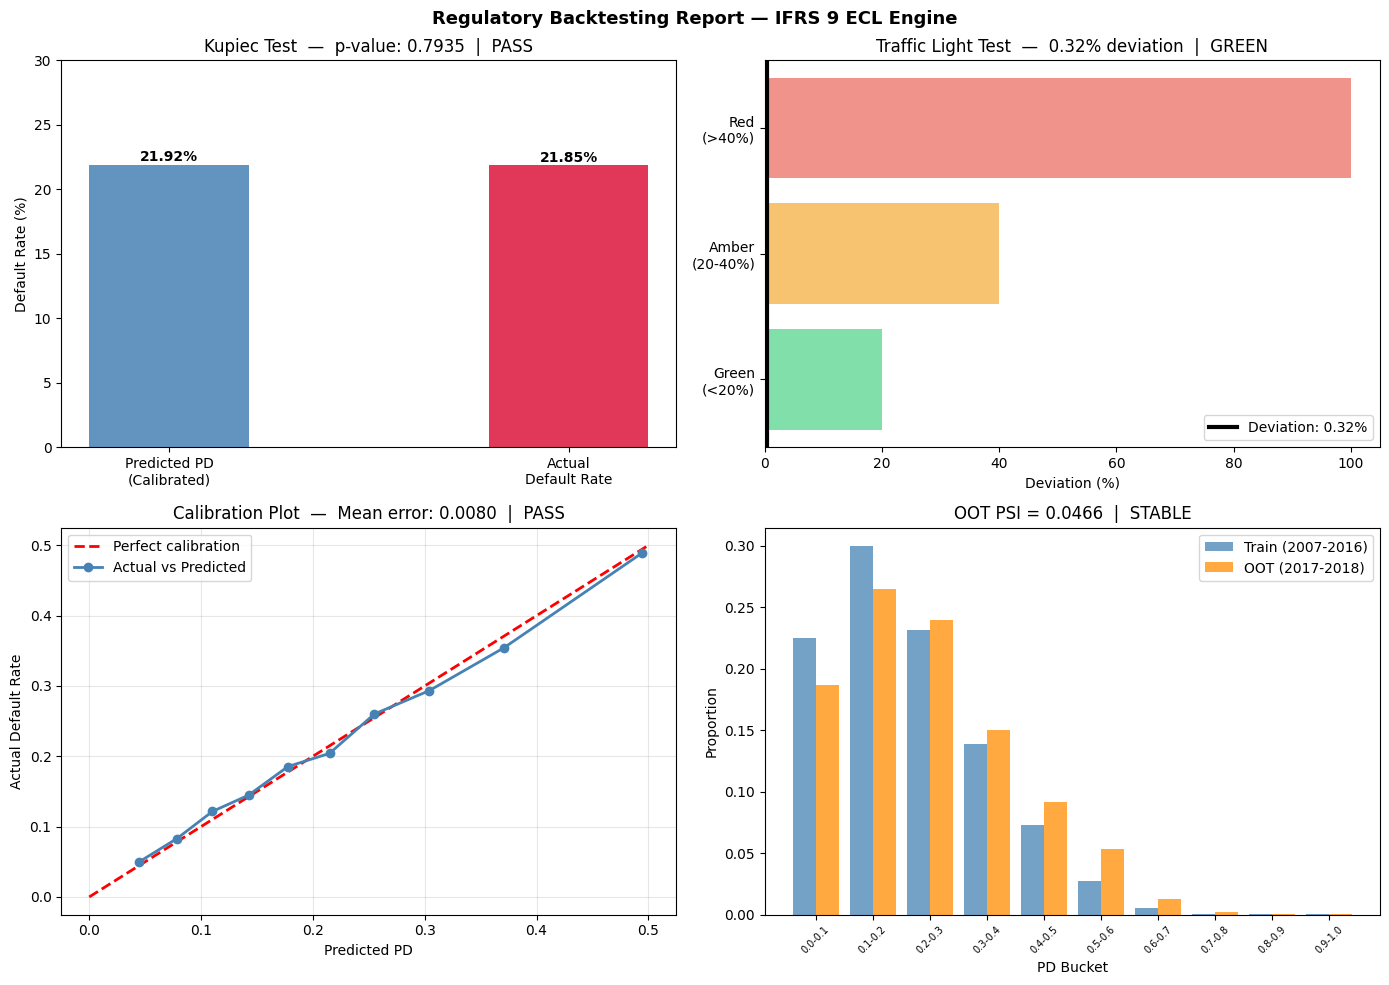

Backtesting report saved to reports/backtesting_report.png

All 4 regulatory backtests PASSED
   Kupiec Test   : PASS  (p-value: 0.7935)
   Traffic Light : GREEN (deviation: 0.32%)
   Calibration   : PASS  (mean error: 0.0080)
   OOT PSI       : STABLE (PSI: 0.0466)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regulatory Backtesting Report — IFRS 9 ECL Engine',
             fontsize=13, fontweight='bold')

# 1. Kupiec Test — predicted vs actual default rate
categories = ['Predicted PD\n(Calibrated)', 'Actual\nDefault Rate']
values     = [mean_predicted_pd * 100, actual_dr * 100]
bar_colors = ['steelblue', 'crimson']
bars = axes[0, 0].bar(categories, values, color=bar_colors,
                      width=0.4, alpha=0.85)
axes[0, 0].set_title(f'Kupiec Test  —  p-value: {p_value:.4f}  |  PASS')
axes[0, 0].set_ylabel('Default Rate (%)')
axes[0, 0].set_ylim(0, 30)
for bar, val in zip(bars, values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f'{val:.2f}%', ha='center', fontweight='bold')

# 2. Traffic Light — deviation gauge
zone_labels = ['Green\n(<20%)', 'Amber\n(20-40%)', 'Red\n(>40%)']
thresholds  = [20, 40, 100]
zone_colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0, 1].barh(zone_labels, thresholds, color=zone_colors, alpha=0.6)
axes[0, 1].axvline(deviation_pct, color='black', linewidth=3,
                   label=f'Deviation: {deviation_pct:.2f}%')
axes[0, 1].set_title(f'Traffic Light Test  —  {deviation_pct:.2f}% deviation  |  GREEN')
axes[0, 1].set_xlabel('Deviation (%)')
axes[0, 1].legend()

# 3. Calibration plot — predicted vs actual by bucket
calib_plot = pd_preds.groupby('pd_bucket', observed=True).agg(
    predicted = ('pd_probability', 'mean'),
    actual    = ('actual_default', 'mean')
)
axes[1, 0].plot([0, 0.5], [0, 0.5], 'r--', lw=2, label='Perfect calibration')
axes[1, 0].plot(calib_plot['predicted'], calib_plot['actual'],
                'o-', color='steelblue', lw=2, markersize=6,
                label='Actual vs Predicted')
axes[1, 0].set_xlabel('Predicted PD')
axes[1, 0].set_ylabel('Actual Default Rate')
axes[1, 0].set_title(f'Calibration Plot  —  Mean error: {mean_calib_error:.4f}  |  PASS')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. OOT PSI — training vs OOT distribution
bin_labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins) - 1)]
x_pos = range(len(bin_labels))
axes[1, 1].bar(x_pos, train_dist, width=0.4, alpha=0.75,
               color='steelblue', label='Train (2007-2016)')
axes[1, 1].bar([x + 0.4 for x in x_pos], oot_dist, width=0.4, alpha=0.75,
               color='darkorange', label='OOT (2017-2018)')
axes[1, 1].set_title(f'OOT PSI = {psi:.4f}  |  STABLE')
axes[1, 1].set_xlabel('PD Bucket')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].set_xticks([x + 0.2 for x in x_pos])
axes[1, 1].set_xticklabels(bin_labels, rotation=45, fontsize=7)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../reports/backtesting_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("Backtesting report saved to reports/backtesting_report.png")
print(f"\nAll 4 regulatory backtests PASSED")
print(f"   Kupiec Test   : PASS  (p-value: {p_value:.4f})")
print(f"   Traffic Light : GREEN (deviation: {deviation_pct:.2f}%)")
print(f"   Calibration   : PASS  (mean error: {mean_calib_error:.4f})")
print(f"   OOT PSI       : STABLE (PSI: {psi:.4f})")